# Visualizing Clusters with scikit-learn and Plotly

## Week 8 Exercise Program (Program S. No. 17)

**Date:** 03/09/2026

### Problem Statement
Perform K-means clustering on the Iris dataset and visualize the clusters using an interactive 3D scatter
plot in Plotly.

### Dataset
Built-in Iris dataset from scikit-learn (`sklearn.datasets.load_iris`): 150 samples, 4 numeric features
(sepal length, sepal width, petal length, petal width in cm) and 3 species (setosa, versicolor, virginica).
No external dataset URL is required.

In [1]:
# Step 1: Import the required libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings("ignore")

# Plotly renderer: interactive figure inside Jupyter + a static PNG copy of every chart
# (the PNG is what GitHub / PDF previews show, because they cannot run interactive Plotly)
try:
    import kaleido  # noqa: F401  (only needed for the static PNG copies)
    pio.renderers.default = "plotly_mimetype+png"
    pio.renderers["png"].width = 900
    pio.renderers["png"].height = 550
    pio.renderers["png"].scale = 2
except ImportError:
    pio.renderers.default = "plotly_mimetype+notebook"


In [2]:
# Step 2: Load the Iris dataset into a pandas DataFrame
iris = load_iris(as_frame=True)

df = iris.frame.rename(columns={
    "sepal length (cm)": "Sepal Length (cm)",
    "sepal width (cm)": "Sepal Width (cm)",
    "petal length (cm)": "Petal Length (cm)",
    "petal width (cm)": "Petal Width (cm)"
})
df["Species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="target")

feature_columns = ["Sepal Length (cm)", "Sepal Width (cm)", "Petal Length (cm)", "Petal Width (cm)"]

print("Dataset Shape:", df.shape)
print("\nSpecies Counts:")
print(df["Species"].value_counts())

df.head(10)

Dataset Shape: (150, 5)

Species Counts:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
# Step 3: Standardize the features so that every measurement has equal weight in the distance calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_columns])

print("Scaled feature matrix shape:", X_scaled.shape)
print("First 5 scaled rows:")
print(np.round(X_scaled[:5], 3))

Scaled feature matrix shape: (150, 4)
First 5 scaled rows:
[[-0.901  1.019 -1.34  -1.315]
 [-1.143 -0.132 -1.34  -1.315]
 [-1.385  0.328 -1.397 -1.315]
 [-1.507  0.098 -1.283 -1.315]
 [-1.022  1.249 -1.34  -1.315]]


 k  Inertia (WCSS)  Silhouette Score
 1         600.000               NaN
 2         222.362             0.582
 3         139.820             0.460
 4         114.093             0.387
 5          90.928             0.346
 6          81.544             0.317
 7          72.631             0.320
 8          62.541             0.339
 9          55.119             0.342
10          47.391             0.352


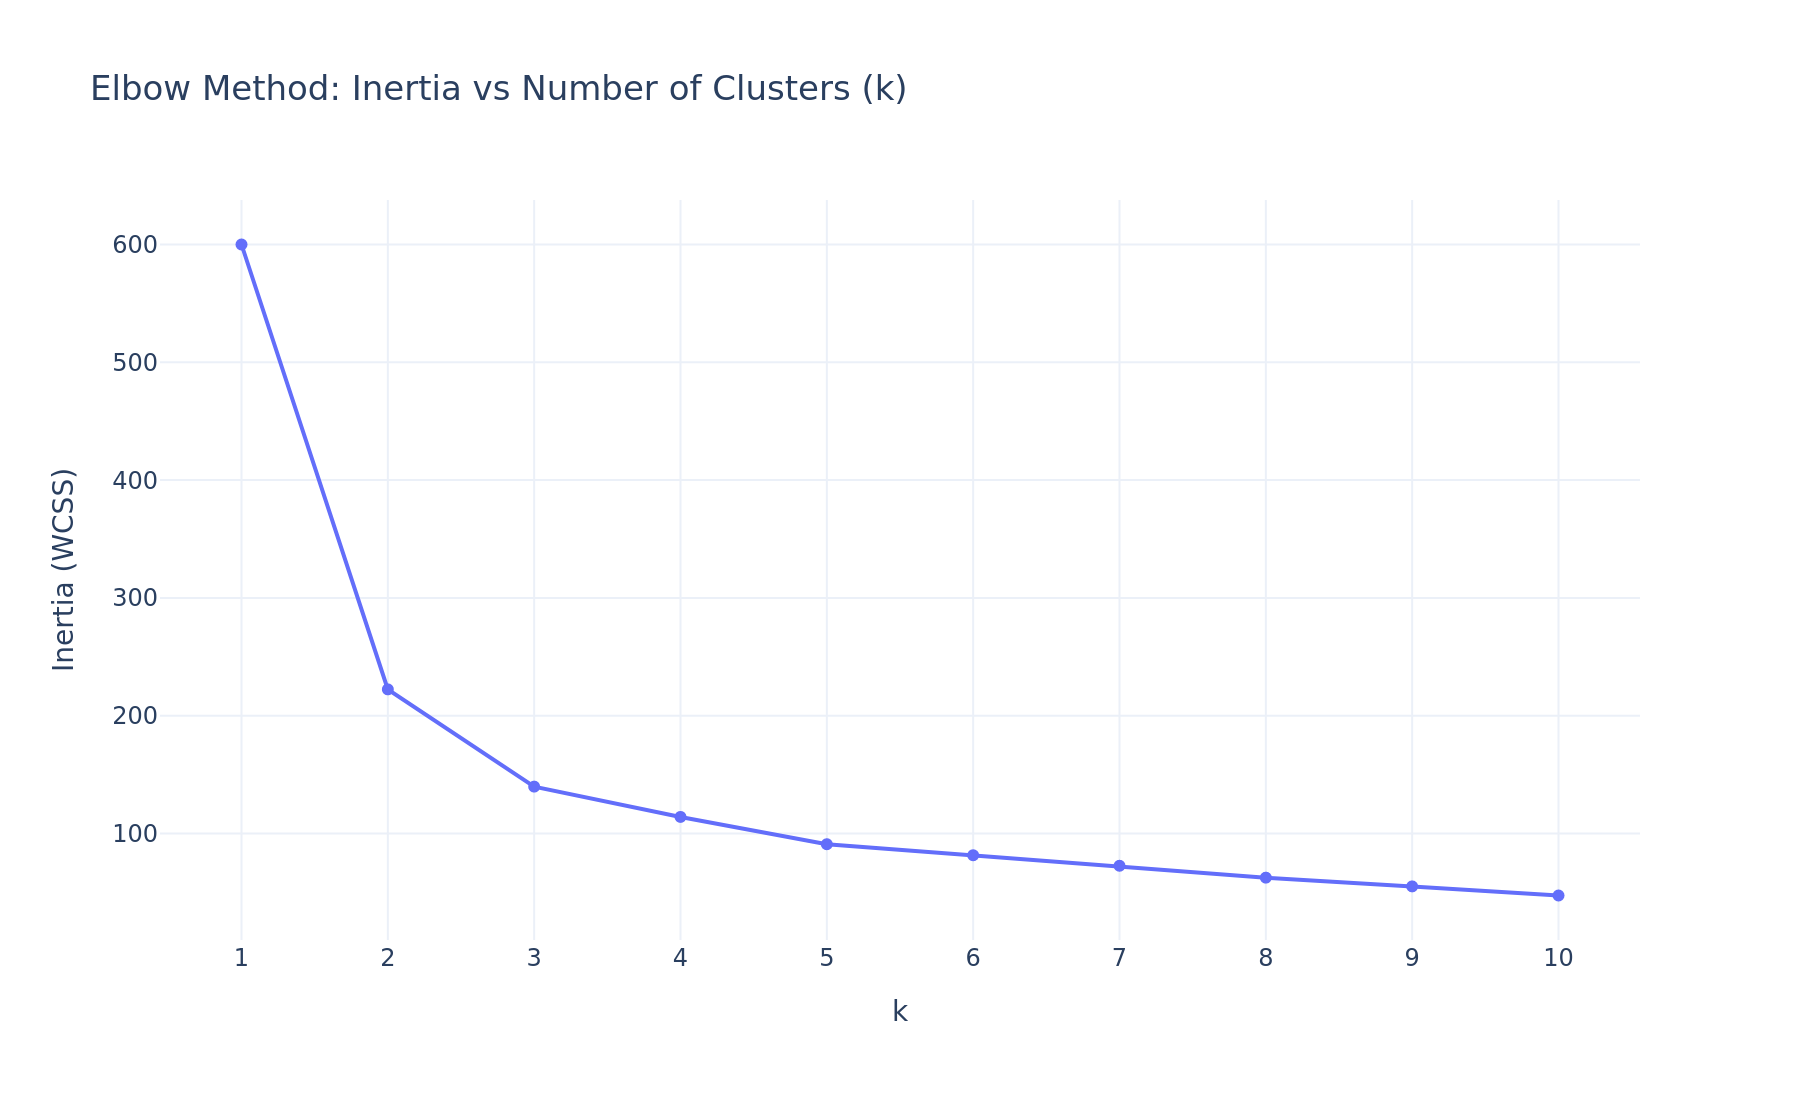

In [4]:
# Step 4: Elbow method and silhouette score to choose the number of clusters (k)
k_values = range(1, 11)
inertia = []
silhouette = []

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels) if k > 1 else np.nan)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia (WCSS)": np.round(inertia, 3),
    "Silhouette Score": np.round(silhouette, 3)
})
print(elbow_df.to_string(index=False))

fig_elbow = px.line(
    elbow_df,
    x="k",
    y="Inertia (WCSS)",
    markers=True,
    title="Elbow Method: Inertia vs Number of Clusters (k)"
)
fig_elbow.update_layout(width=900, height=550, template="plotly_white", xaxis=dict(dtick=1))

fig_elbow.show()

In [5]:
# Step 5: Fit K-means with k = 3 (three Iris species) and assign cluster labels
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df["Cluster"] = "Cluster " + df["Cluster"].astype(str)

print("Number of iterations to converge:", kmeans.n_iter_)
print("Final inertia (WCSS):", round(kmeans.inertia_, 3))

print("\nCluster Sizes:")
print(df["Cluster"].value_counts().sort_index())

df.head(10)

Number of iterations to converge: 4
Final inertia (WCSS): 139.82

Cluster Sizes:
Cluster
Cluster 0    53
Cluster 1    50
Cluster 2    47
Name: count, dtype: int64


,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species,Cluster
0,5.1,3.5,1.4,0.2,setosa,Cluster 1
1,4.9,3.0,1.4,0.2,setosa,Cluster 1
2,4.7,3.2,1.3,0.2,setosa,Cluster 1
3,4.6,3.1,1.5,0.2,setosa,Cluster 1
4,5.0,3.6,1.4,0.2,setosa,Cluster 1
5,5.4,3.9,1.7,0.4,setosa,Cluster 1
6,4.6,3.4,1.4,0.3,setosa,Cluster 1
7,5.0,3.4,1.5,0.2,setosa,Cluster 1
8,4.4,2.9,1.4,0.2,setosa,Cluster 1
9,4.9,3.1,1.5,0.1,setosa,Cluster 1


In [6]:
# Step 6: Compare the discovered clusters with the actual species
comparison = pd.crosstab(df["Cluster"], df["Species"])
print("Cluster vs Species Cross-tabulation:")
print(comparison)

sil = silhouette_score(X_scaled, kmeans.labels_)
ari = adjusted_rand_score(iris.target, kmeans.labels_)

print("\nSilhouette Score (k = 3)      :", round(sil, 3))
print("Adjusted Rand Index vs species:", round(ari, 3))

# percentage of points whose cluster matches the dominant species of that cluster
correctly_grouped = comparison.max(axis=1).sum()
print("Points grouped with their dominant species:", correctly_grouped, "of", len(df),
      "(", round(correctly_grouped / len(df) * 100, 2), "% )")

Cluster vs Species Cross-tabulation:
Species    setosa  versicolor  virginica
Cluster                                 
Cluster 0       0          39         14
Cluster 1      50           0          0
Cluster 2       0          11         36

Silhouette Score (k = 3)      : 0.46
Adjusted Rand Index vs species: 0.62
Points grouped with their dominant species: 125 of 150 ( 83.33 % )


In [7]:
# Step 7: Cluster centres converted back to the original units (cm)
centers_cm = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(centers_cm, columns=feature_columns).round(3)
centers_df.insert(0, "Cluster", ["Cluster 0", "Cluster 1", "Cluster 2"])

print("Cluster Centres (original units):")
print(centers_df.to_string(index=False))

Cluster Centres (original units):
  Cluster  Sepal Length (cm)  Sepal Width (cm)  Petal Length (cm)  Petal Width (cm)
Cluster 0              5.802             2.674              4.370             1.413
Cluster 1              5.006             3.428              1.462             0.246
Cluster 2              6.781             3.096              5.511             1.972


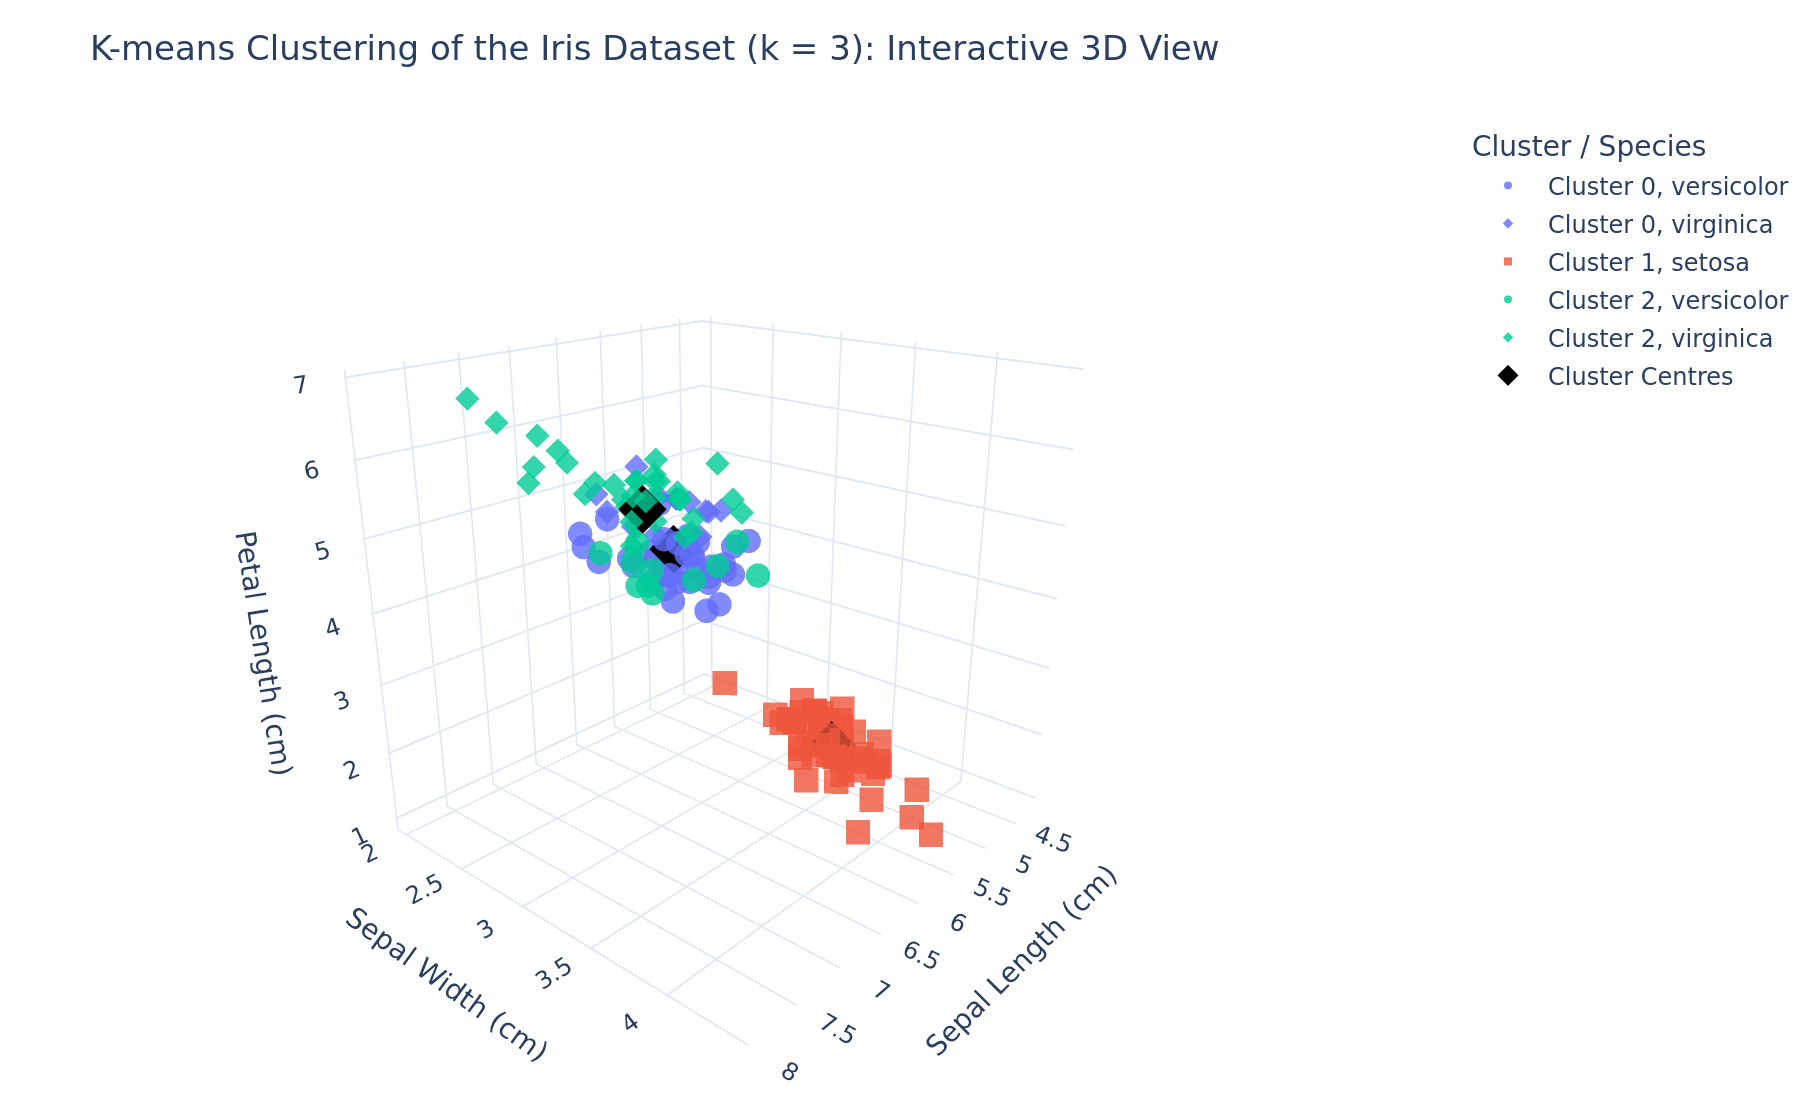

In [8]:
# Step 8: Interactive 3D scatter plot of the clusters (with cluster centres marked)
fig = px.scatter_3d(
    df.sort_values("Cluster"),
    x="Sepal Length (cm)",
    y="Sepal Width (cm)",
    z="Petal Length (cm)",
    color="Cluster",
    symbol="Species",
    hover_data={"Petal Width (cm)": True},
    title="K-means Clustering of the Iris Dataset (k = 3): Interactive 3D View",
    opacity=0.8
)
fig.update_traces(marker=dict(size=4))

# add the three cluster centres as large black diamonds
fig.add_trace(go.Scatter3d(
    x=centers_df["Sepal Length (cm)"],
    y=centers_df["Sepal Width (cm)"],
    z=centers_df["Petal Length (cm)"],
    mode="markers",
    marker=dict(size=8, color="black", symbol="diamond"),
    hovertext=centers_df["Cluster"] + " centre",
    name="Cluster Centres"
))

fig.update_layout(
    width=900,
    height=650,
    legend_title_text="Cluster / Species",
    margin=dict(l=0, r=0, b=0, t=60),
    scene=dict(
        xaxis_title="Sepal Length (cm)",
        yaxis_title="Sepal Width (cm)",
        zaxis_title="Petal Length (cm)",
        aspectmode="cube",
        camera=dict(eye=dict(x=1.7, y=1.5, z=0.9))
    ),
    template="plotly_white"
)

fig.show()

In [9]:
# Step 9: Save the interactive chart, static images and the clustered dataset
fig.write_html("program17_kmeans_3d_scatter.html")
print("Interactive 3D scatter plot saved as program17_kmeans_3d_scatter.html")

try:
    fig.write_image("program17_kmeans_3d_scatter.png", width=900, height=650, scale=2)
    fig_elbow.write_image("program17_elbow_plot.png", width=900, height=550, scale=2)
    print("Static images saved as program17_kmeans_3d_scatter.png and program17_elbow_plot.png")
except Exception as error:
    print("Static image not saved (kaleido not available):", error)

df.to_csv("program17_iris_kmeans_clusters.csv", index=False)
print("Clustered dataset saved as program17_iris_kmeans_clusters.csv")

Interactive 3D scatter plot saved as program17_kmeans_3d_scatter.html


Static images saved as program17_kmeans_3d_scatter.png and program17_elbow_plot.png
Clustered dataset saved as program17_iris_kmeans_clusters.csv


In [10]:
# Step 10: Summary of the analysis
print("K-MEANS CLUSTERING SUMMARY")
print("-" * 45)
print("Total samples               :", len(df))
print("Features used               :", len(feature_columns), "(standardized)")
print("Number of clusters (k)      : 3")
print("Cluster sizes               :", df["Cluster"].value_counts().sort_index().tolist())
print("Silhouette score            :", round(sil, 3))
print("Adjusted Rand Index         :", round(ari, 3))
print("Agreement with species      :", round(correctly_grouped / len(df) * 100, 2), "%")
print("Perfectly separated species : setosa")
print("Overlapping species         : versicolor and virginica")

K-MEANS CLUSTERING SUMMARY
---------------------------------------------
Total samples               : 150
Features used               : 4 (standardized)
Number of clusters (k)      : 3
Cluster sizes               : [53, 50, 47]
Silhouette score            : 0.46
Adjusted Rand Index         : 0.62
Agreement with species      : 83.33 %
Perfectly separated species : setosa
Overlapping species         : versicolor and virginica
